In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv
/kaggle/input/notebooks/sakshichougule/marketing-attribution-analysis/__results__.html
/kaggle/input/notebooks/sakshichougule/marketing-attributio

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/organizations
/kaggle/input/datasets/organizations/olistbr
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce
    olist_customers_dataset.csv
    olist_sellers_dataset.csv
    olist_order_reviews_dataset.csv
    olist_order_items_dataset.csv
    olist_products_dataset.csv
    olist_geolocation_dataset.csv
    product_category_name_translation.csv
    olist_orders_dataset.csv
    olist_order_payments_dataset.csv
/kaggle/input/notebooks
/kaggle/input/notebooks/sakshichougule
/kaggle/input/notebooks/sakshichougule/marketing-attribution-analysis
    __results__.html
    __notebook__.ipynb
    __output__.json
    rfm_dataset.csv
    master_dataset.csv
    custom.css


In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
import os
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/organizations
/kaggle/input/datasets/organizations/olistbr
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce
/kaggle/input/notebooks
/kaggle/input/notebooks/sakshichougule
/kaggle/input/notebooks/sakshichougule/marketing-attribution-analysis
/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/organizations
/kaggle/input/datasets/organizations/olistbr
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce
/kaggle/input/notebooks
/kaggle/input/notebooks/sakshichougule
/kaggle/input/notebooks/sakshichougule/marketing-attribution-analysis


In [4]:
import pandas as pd

master_df = pd.read_csv('/kaggle/input/notebooks/sakshichougule/marketing-attribution-analysis/master_dataset.csv')
master_df.head()

,order_id,customer_unique_id,order_purchase_timestamp,payment_value,product_category_name,geolocation_city
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2.0,utilidades_domesticas,sao paulo
1,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2.0,utilidades_domesticas,sao paulo
2,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2.0,utilidades_domesticas,sao paulo
3,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2.0,utilidades_domesticas,sao paulo
4,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2.0,utilidades_domesticas,sao paulo


# Hypothesis testing



👉 Do high-value customers spend significantly more than low-value customers?

In [5]:
#CREATE CUSTOMER SPENDING

In [6]:
customer_spend = master_df.groupby('customer_unique_id')['payment_value'].sum().reset_index()

check distribution

<Axes: >

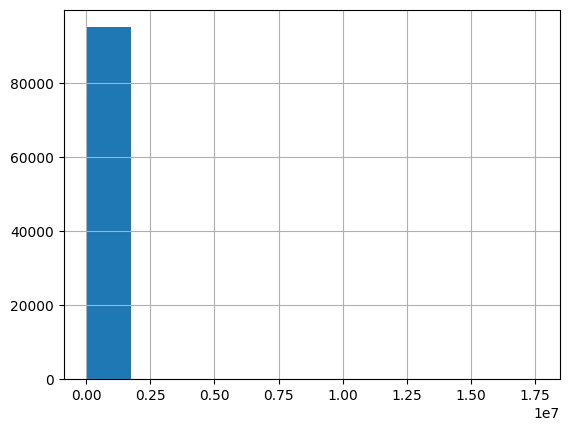

In [7]:
customer_spend['payment_value'].hist()

data is EXTREMELY RIGHT-SKEWED
Most customers spend very small amounts
Few customers spend VERY large amounts (outliers)

Real business behavior (few high spenders dominate revenue)

In [8]:
!pip install matplotlib
import matplotlib.pyplot as plt

EXTRACT TWO GROUPS

In [9]:
q1 = customer_spend['payment_value'].quantile(0.33)
q2 = customer_spend['payment_value'].quantile(0.66)

def segment(x):
    if x <= q1:
        return 'Low'
    elif x <= q2:
        return 'Medium'
    else:
        return 'High'

customer_spend['segment'] = customer_spend['payment_value'].apply(segment)

In [10]:
high = customer_spend[customer_spend['segment']=='High']['payment_value']
low = customer_spend[customer_spend['segment']=='Low']['payment_value']

In [11]:
#“Due to heavy skewness and outliers in customer spending, I applied log transformation 
#to ensure meaningful comparison between segments.”

# LOG TRANSFORMATION

✔ Compresses large values ✔ Spreads small values ✔ Makes pattern visible

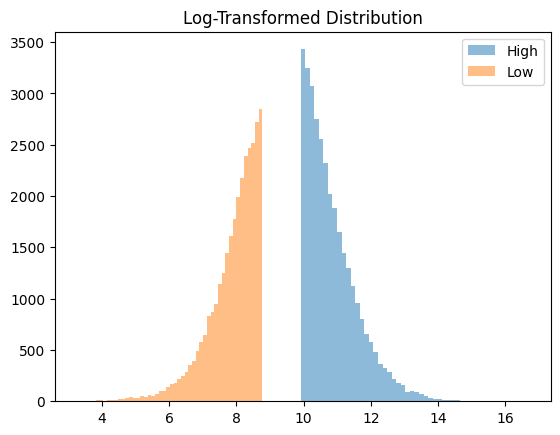

In [12]:


high_log = np.log1p(high)
low_log = np.log1p(low)

plt.hist(high_log, bins=50, alpha=0.5, label='High')
plt.hist(low_log, bins=50, alpha=0.5, label='Low')

plt.legend()
plt.title("Log-Transformed Distribution")
plt.show()

 >   The clear separation indicates strong segmentation quality, validating that customer groups are meaningfully distinct for targeted strategies.”

# T-TEST

> ✅ Hypothesis:

👉# **** > Do high-value customers spend significantly more than low-value customers?

In [13]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_log, low_log, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 484.51798203334414
P-value: 0.0


In [14]:
if p_value < 0.05:
    print("✅ Significant difference between High and Low spenders")
else:
    print("❌ No significant difference")

✅ Significant difference between High and Low spenders


There is a statistically significant difference between high-value and low-value customers’ spending.

# Mann-Whitney U TEST


In [15]:
from scipy.stats import mannwhitneyu

u_stat, p_val = mannwhitneyu(high, low, alternative='two-sided')

print("U-statistic:", u_stat)
print("P-value:", p_val)

U-statistic: 1015916553.0
P-value: 0.0


In [16]:
Reviews = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv")
Reviews.head()



,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


# Distribution of Ratings

<Axes: xlabel='review_score'>

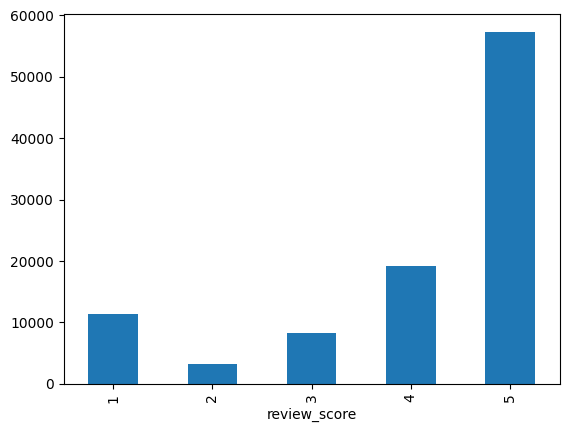

In [17]:
Reviews['review_score'].value_counts().sort_index().plot(kind='bar')

In [18]:
payments=pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv")

In [19]:
review_payment = Reviews.merge(payments, on='order_id', how='inner')
review_payment.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,1,credit_card,8,397.26
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,1,credit_card,1,88.09
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,1,credit_card,1,194.12
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,1,credit_card,1,222.84
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,1,credit_card,10,1333.25


# Does rating affect spending?

# Rating vs Spending

In [20]:
review_payment.groupby('review_score')['payment_value'].mean()

review_score
1    186.388143
2    163.374048
3    145.134606
4    147.976925
5    149.697435
Name: payment_value, dtype: float64

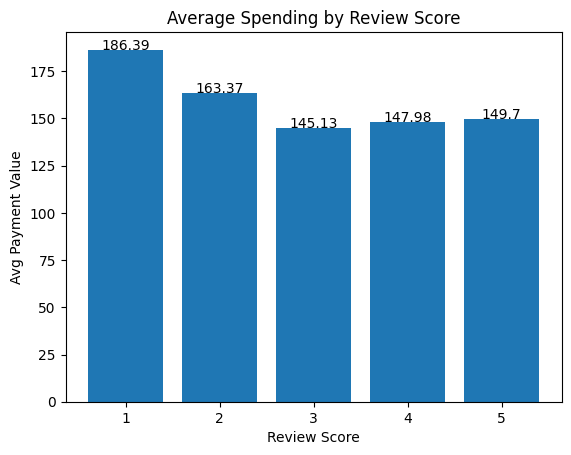

In [21]:
avg_spend = review_payment.groupby('review_score')['payment_value'].mean()

plt.figure()
plt.bar(avg_spend.index, avg_spend.values)

plt.title("Average Spending by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Avg Payment Value")

for i, v in enumerate(avg_spend.values):
    plt.text(i+1, v, round(v,2), ha='center')

plt.show()

**** Customers who give low ratings are spending more

# Correlation Analysis

In [22]:
review_payment[['review_score','payment_value']].corr()

,review_score,payment_value
review_score,1.000000,-0.046513
payment_value,-0.046513,1.000000


 A correlation value of -0.04 indicates a very weak negative  relationship between Payment_Value  and review score.

 # TEXT ANALYSIS

Sentiment Analysis

In [23]:
def map_sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

review_payment['sentiment'] = review_payment['review_score'].apply(map_sentiment)

In [24]:
review_payment.groupby('sentiment')['payment_value'].mean()

sentiment
Negative    181.380502
Neutral     145.134606
Positive    149.266219
Name: payment_value, dtype: float64

Negative customers spend the MOST


✔ Low ratings → higher spending
✔ Negative sentiment → higher spending

High spend → higher expectations  ,
Expensive orders → more issues noticed ,
Delivery/service gaps hurt premium users more

<Axes: xlabel='sentiment', ylabel='payment_value'>

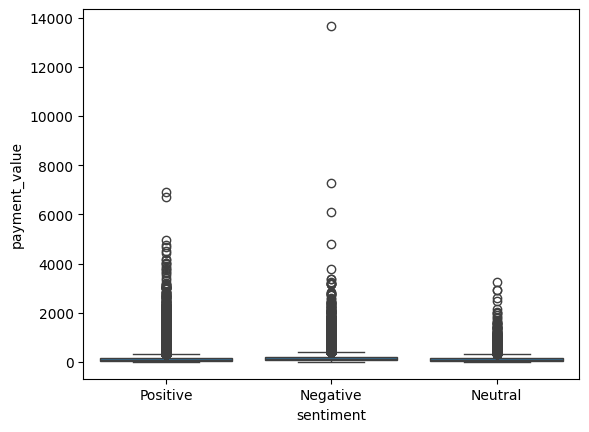

In [25]:
import seaborn as sns

sns.boxplot(x='sentiment', y='payment_value', data=review_payment)

In [26]:
high_rating = review_payment[review_payment['review_score'] >= 4]['payment_value']
low_rating = review_payment[review_payment['review_score'] <= 2]['payment_value']

In [27]:
import numpy as np
from scipy.stats import ttest_ind

high_log = np.log1p(high_rating)
low_log = np.log1p(low_rating)

t_stat, p_value = ttest_ind(high_log, low_log, equal_var=False)

print("P-value:", p_value)

P-value: 3.67534001251794e-53


# There IS a statistically significant difference in spending between your groups (low vs high ratings)

The t-test produced an extremely low p-value (~3.67e-53), indicating a statistically significant difference in spending between customer rating groups. Interestingly, lower-rated customers tend to spend more, suggesting that high-value customers may have higher expectations and are more critical.”

# DELIVERY TIME ANALYSIS

In [28]:
orders=pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv")

In [29]:
#✅ Actual Delivery Time

In [30]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

In [31]:
orders['delivery_time'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# Delivery Time Distribution

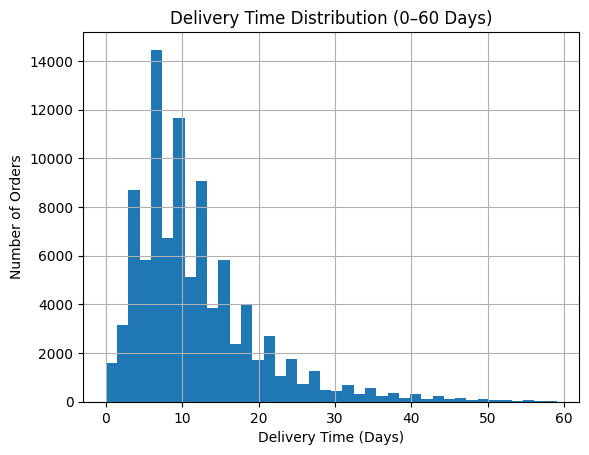

In [32]:
orders[orders['delivery_time'] < 60]['delivery_time'].hist(bins=40)

plt.title("Delivery Time Distribution (0–60 Days)")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

The delivery time distribution is right-skewed, with most orders delivered within 30 days but a small number of extreme delays significantly affecting the distribution.”

# DELIVERY DELAY

Delay = Actual vs Estimated

In [33]:
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

In [34]:
orders['delay'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

In [35]:
def delay_category(x):
    if x > 0:
        return 'Late'
    elif x < 0:
        return 'Early'
    else:
        return 'On Time'

orders['delivery_status'] = orders['delay'].apply(delay_category)

<Axes: xlabel='delivery_status'>

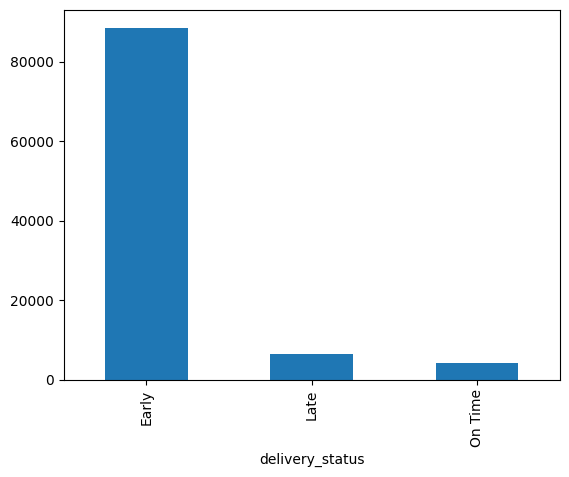

In [36]:
orders['delivery_status'].value_counts().plot(kind='bar')

# IMPACT ON CUSTOMER SATISFACTION

In [37]:
orders.columns
review_payment.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'sentiment'],
      dtype='object')

In [38]:
order_payment = pd.merge(
    orders,
    review_payment,
    on='order_id',
    how='inner'
)

In [39]:
order_payment.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delay,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,sentiment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,1,credit_card,1,18.12,Positive
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,3,voucher,1,2.00,Positive
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2,voucher,1,18.59,Positive
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,...,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,1,boleto,1,141.46,Positive
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,...,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1,credit_card,3,179.12,Positive


In [40]:
order_payment['delay'] = (
    order_payment['order_delivered_customer_date'] - order_payment['order_estimated_delivery_date']
).dt.days

In [41]:
order_payment.groupby('delivery_status')['review_score'].mean()

delivery_status
Early      4.291077
Late       2.266647
On Time    2.456731
Name: review_score, dtype: float64

# IMPACT ON REVENUE

In [42]:
#Do expensive orders get delayed more?

In [43]:
order_payment.groupby('delivery_status')['payment_value'].mean()

delivery_status
Early      151.586189
Late       168.103334
On Time    175.799670
Name: payment_value, dtype: float64

# PROCESS EFFICIENCY ANALYSIS

⏱️ Approval Time

In [44]:
order_payment['order_approved_at'] = pd.to_datetime(order_payment['order_approved_at']) 
order_payment['order_delivered_carrier_date'] = pd.to_datetime(order_payment['order_delivered_carrier_date'])

In [45]:
order_payment['approval_time'] = (
    order_payment['order_approved_at'] - order_payment['order_purchase_timestamp']
).dt.total_seconds() / 3600

 # Carrier Handling Time

In [46]:
order_payment['carrier_time'] = (
    order_payment['order_delivered_carrier_date'] - order_payment['order_approved_at']
).dt.days

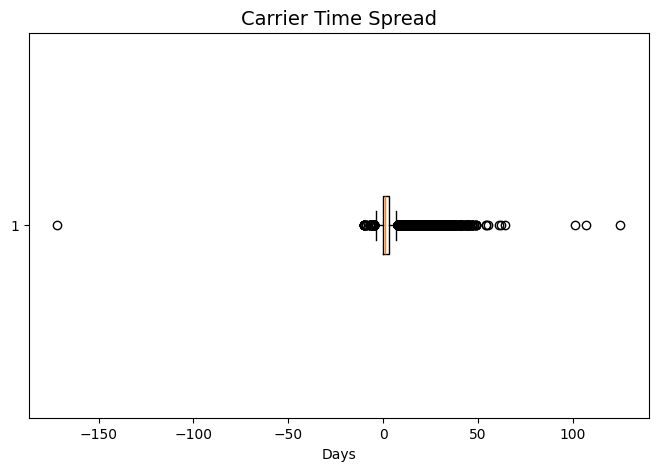

In [47]:
plt.figure(figsize=(8,5))

plt.boxplot(order_payment['carrier_time'].dropna(), vert=False)

plt.title("Carrier Time Spread", fontsize=14)
plt.xlabel("Days")

plt.show()

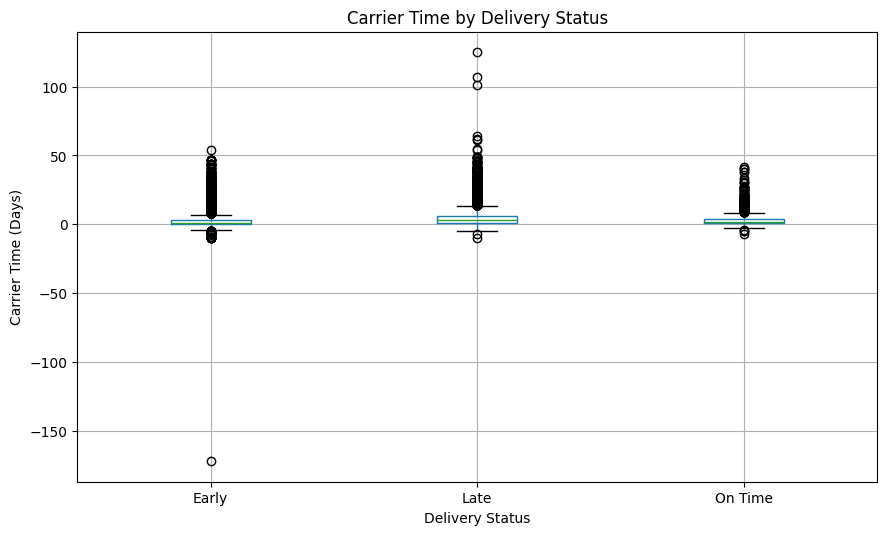

In [48]:
order_payment.boxplot(column='carrier_time', by='delivery_status', figsize=(10,6))

plt.title("Carrier Time by Delivery Status")
plt.suptitle("")
plt.xlabel("Delivery Status")
plt.ylabel("Carrier Time (Days)")

plt.show()

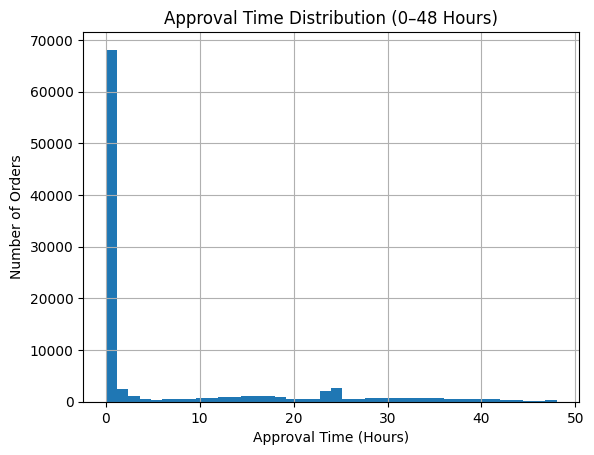

In [49]:
order_payment[order_payment['approval_time'] < 48]['approval_time'].hist(bins=40)

plt.title("Approval Time Distribution (0–48 Hours)")
plt.xlabel("Approval Time (Hours)")
plt.ylabel("Number of Orders")

plt.show()

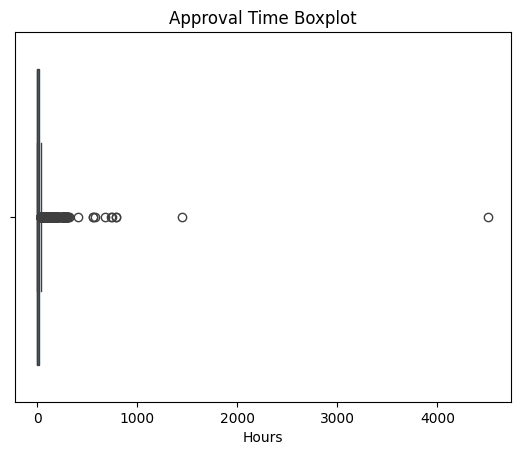

In [50]:
import seaborn as sns

sns.boxplot(x=order_payment['approval_time'])

plt.title("Approval Time Boxplot")
plt.xlabel("Hours")

plt.show()

# Does approval delay affect ratings?

In [51]:
order_payment.groupby(pd.cut(order_payment['approval_time'], bins=[0,1,5,10,24,30,48]))['review_score'].mean()

/tmp/ipykernel_55/2345270776.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order_payment.groupby(pd.cut(order_payment['approval_time'], bins=[0,1,5,10,24,30,48]))['review_score'].mean()


approval_time
(0, 1]      4.100329
(1, 5]      4.040440
(5, 10]     4.146685
(10, 24]    4.096226
(24, 30]    4.033812
(30, 48]    4.052757
Name: review_score, dtype: float64

In [52]:
# There is no significant difference in  Average review score is not observed due to approval time changes or slots.

# Shipping Time

In [53]:
order_payment['shipping_time'] = (
    order_payment['order_delivered_customer_date'] - order_payment['order_delivered_carrier_date']
).dt.days

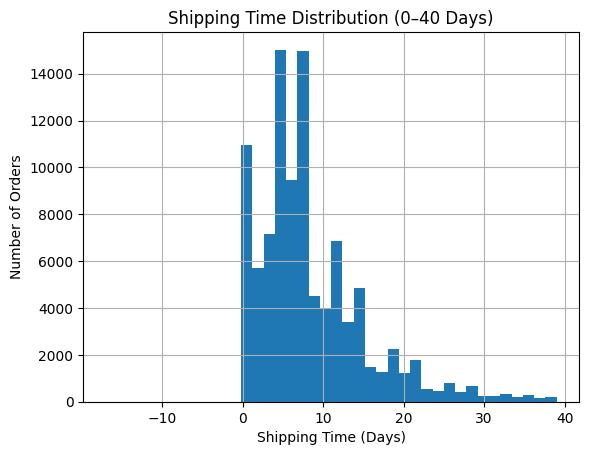

In [54]:
order_payment[order_payment['shipping_time'] < 40]['shipping_time'].hist(bins=40)

plt.title("Shipping Time Distribution (0–40 Days)")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

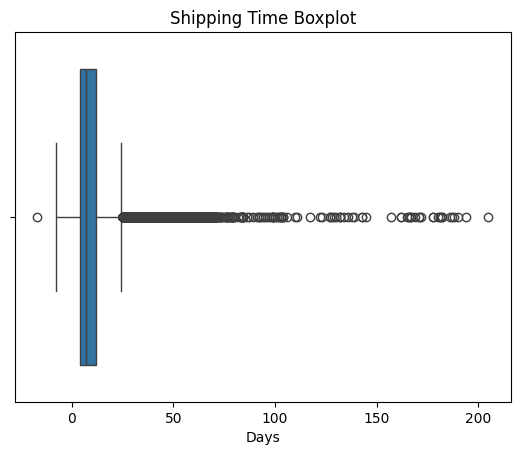

In [55]:
import seaborn as sns

sns.boxplot(x=order_payment['shipping_time'])

plt.title("Shipping Time Boxplot")
plt.xlabel("Days")

plt.show()

# IMPACT OF SHIPPING TIME ON CUSTOMER SATISFACTION

In [56]:
order_payment.groupby(
    pd.cut(order_payment['shipping_time'], bins=[0,5,10,20,40])
)['review_score'].mean()

/tmp/ipykernel_55/828580087.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order_payment.groupby(


shipping_time
(0, 5]      4.340546
(5, 10]     4.283744
(10, 20]    4.089215
(20, 40]    2.925617
Name: review_score, dtype: float64

/tmp/ipykernel_55/2136280317.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order_payment.groupby('shipping_bucket')['review_score'].mean().plot(kind='bar')


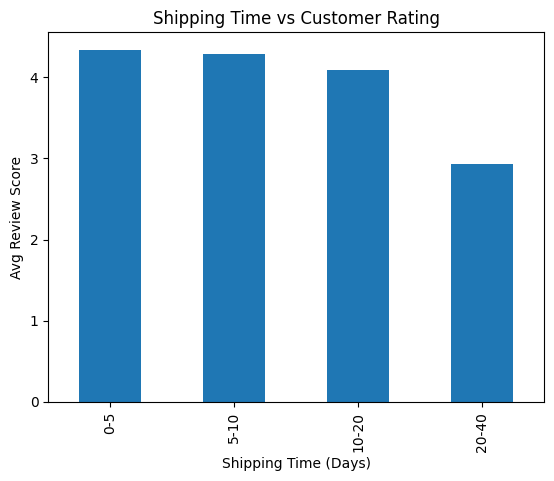

In [57]:
order_payment['shipping_bucket'] = pd.cut(
    order_payment['shipping_time'],
    bins=[0,5,10,20,40],
    labels=['0-5','5-10','10-20','20-40']
)

order_payment.groupby('shipping_bucket')['review_score'].mean().plot(kind='bar')

plt.title("Shipping Time vs Customer Rating")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Avg Review Score")

plt.show()

The analysis shows a clear negative relationship between shipping time and customer satisfaction. Orders delivered within 5 days receive the highest ratings, while deliveries taking over 20 days see a significant drop in customer satisfaction. This indicates that delivery speed is a critical driver of customer experience.”

“Shipping time has a direct and measurable impact on customer satisfaction, with delays beyond 10 days leading to a consistent decline in ratings.”

# WHICH PART CAUSES DELAY?

In [58]:
order_payment[['approval_time','carrier_time','shipping_time']].mean()

approval_time    10.322388
carrier_time      2.301919
shipping_time     8.858176
dtype: float64

In [59]:
order_payment.groupby('delivery_status')['sentiment'].value_counts()

delivery_status  sentiment
Early            Positive     76626
                 Negative      8617
                 Neutral       7413
Late             Negative      4162
                 Positive      1769
                 Neutral        722
On Time          Negative      2525
                 Positive      1435
                 Neutral        408
Name: count, dtype: int64

In [60]:
pivot_data = order_payment.groupby('delivery_status')['sentiment'].value_counts().unstack()

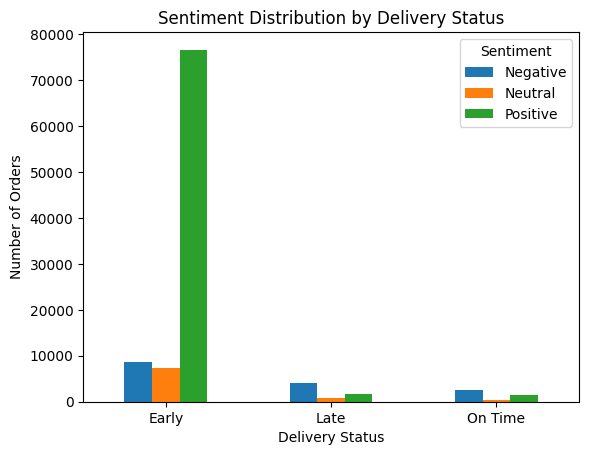

In [61]:


pivot_data.plot(kind='bar')

plt.title("Sentiment Distribution by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)
plt.legend(title="Sentiment")

plt.show()

The sentiment analysis shows a clear relationship between delivery performance and customer experience. Early deliveries generate overwhelmingly positive sentiment, while late deliveries significantly increase negative feedback. Interestingly, on-time deliveries result in mixed sentiment, suggesting that customers value faster-than-expected delivery rather than just meeting expectations.”